### Combinations of Options

Options can be combined to generate interesting investing strategies, here are some examples

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

def bsm_option_prices(S0, K, r, sigma, t):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * t) / sigma / np.sqrt(t)
    d2 = d1 - sigma * np.sqrt(t)

    Ce0 = S0 * scipy.stats.norm.cdf(d1) - K * np.exp(-r * t) * scipy.stats.norm.cdf(d2)
    Pe0 = K * np.exp(-r * t) * scipy.stats.norm.cdf(-d2) - S0 * scipy.stats.norm.cdf(-d1)

    return {'call': Ce0, 
            'put': Pe0}

def payoff_call(St, K):
    return np.maximum(St - K, 0)

def payoff_put(St, K):
    return np.maximum(K - St, 0)

#### BULL-SPREAD
Purchase a call option with strike price K1 < S0

Sell a call option with strike price K2 > S0

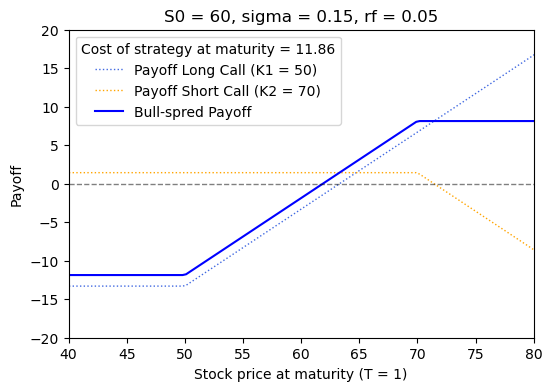

In [19]:
S0 = 60
sigma = 0.15
rf = 0.05
t = 1

K1, K2 = 50, 70
St = np.linspace(0, 120, 401)
# Present day value of options
Ce0_K1 = bsm_option_prices(S0, K1, rf, sigma, t)['call']
Ce0_K2 = bsm_option_prices(S0, K2, rf, sigma, t)['call']

# Maturity value of options
CeT_K1 = Ce0_K1 * np.exp(rf * t) # buy 1
CeT_K2 = Ce0_K2 * np.exp(rf * t) # sell 1

# Cost of strategy at maturity
cost_of_strategy = round(CeT_K1 - CeT_K2, 2)

# Payoffs
poff_call1 = payoff_call(St, K1) -  CeT_K1
poff_call2 = CeT_K2 - payoff_call(St, K2)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.set_title(f'S0 = {S0}, sigma = {sigma}, rf = {rf}')
ax.plot(St, poff_call1, lw=1, ls=':', color='royalblue', label=f'Payoff Long Call (K1 = {K1})')
ax.plot(St, poff_call2, lw=1, ls=':', color='orange', label=f'Payoff Short Call (K2 = {K2})')
ax.plot(St, poff_call1 + poff_call2, color='blue', label='Bull-spred Payoff')
ax.axhline(0, lw=1, ls="--", color='black', alpha=0.5)
ax.set_xlim(40, 80)
ax.set_ylim(-20, 20)
ax.set_xlabel(f'Stock price at maturity (T = {t})')
ax.set_ylabel('Payoff')
ax.legend(title=f"Cost of strategy at maturity = {cost_of_strategy}")
plt.show()

#### BEAR-SPREAD

Purchase a put option with strike price K2 > S0

Sell a put option with strike price K1 < S0

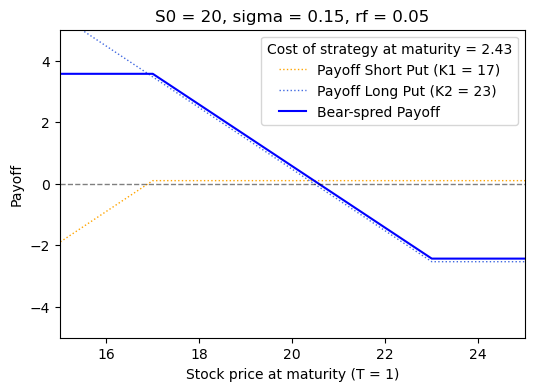

In [20]:
S0 = 20
sigma = 0.15
rf = 0.05
t = 1

K1, K2 = 17, 23
St = np.linspace(0, 40, 401)
# Present day value of options
Pe0_K1 = bsm_option_prices(S0, K1, rf, sigma, t)['put']
Pe0_K2 = bsm_option_prices(S0, K2, rf, sigma, t)['put']

# Maturity value of options
PeT_K1 = Pe0_K1 * np.exp(rf * t) # sell 1
PeT_K2 = Pe0_K2 * np.exp(rf * t) # buy 1

# Cost of strategy at maturity
cost_of_strategy = round(PeT_K2 - PeT_K1, 2)

# Payoffs
poff_put1 = PeT_K1 - payoff_put(St, K1)
poff_put2 = payoff_put(St, K2) - PeT_K2

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.set_title(f'S0 = {S0}, sigma = {sigma}, rf = {rf}')
ax.plot(St, poff_put1, lw=1, ls=':', color='orange', label=f'Payoff Short Put (K1 = {K1})')
ax.plot(St, poff_put2, lw=1, ls=':', color='royalblue', label=f'Payoff Long Put (K2 = {K2})')
ax.plot(St, poff_put1 + poff_put2, color='blue', label='Bear-spred Payoff')
ax.axhline(0, lw=1, ls="--", color='black', alpha=0.5)
ax.set_xlim(15, 25)
ax.set_ylim(-5, 5)

ax.set_xlabel(f'Stock price at maturity (T = {t})')
ax.set_ylabel('Payoff')
ax.legend(title=f"Cost of strategy at maturity = {cost_of_strategy}")
plt.show()

#### BUTTERFLY-SPREAD

Purchase 1 call option with strike price K1 < S0

Purchase 1 call option with strike price K3 > S0

Sell two at-the-money call options

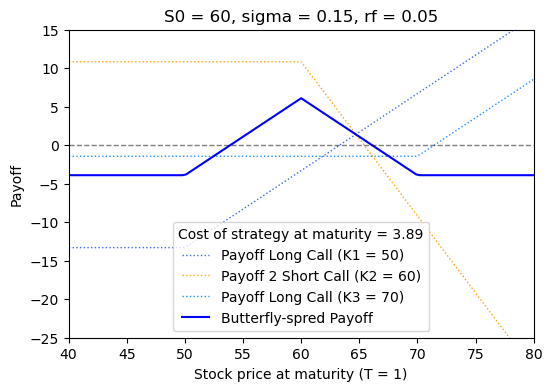

In [27]:
S0 = 60
sigma = 0.15
rf = 0.05
t = 1

K1, K3 = 50, 70
K2 = S0
St = np.linspace(0, 120, 401)
# Present day value of options
Ce0_K1 = bsm_option_prices(S0, K1, rf, sigma, t)['call']
Ce0_K2 = bsm_option_prices(S0, K2, rf, sigma, t)['call']
Ce0_K3 = bsm_option_prices(S0, K3, rf, sigma, t)['call']

# Maturity value of options
CeT_K1 = Ce0_K1 * np.exp(rf * t) # buy 1
CeT_K2 = Ce0_K2 * np.exp(rf * t) # sell 2
CeT_K3 = Ce0_K3 * np.exp(rf * t) # buy 1

# Cost of strategy at maturity
cost_of_strategy = round(CeT_K1 + CeT_K3 - 2 * CeT_K2, 2)

# Payoffs
poff_call1 = payoff_call(St, K1) -  CeT_K1
poff_call2 = CeT_K2 - payoff_call(St, K2)
poff_call3 = payoff_call(St, K3) -  CeT_K3

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.set_title(f'S0 = {S0}, sigma = {sigma}, rf = {rf}')
ax.plot(St, poff_call1, lw=1, ls=':', color='royalblue', label=f'Payoff Long Call (K1 = {K1})')
ax.plot(St, 2 * poff_call2, lw=1, ls=':', color='orange', label=f'Payoff 2 Short Call (K2 = {K2})')
ax.plot(St, poff_call3, lw=1, ls=':', color='dodgerblue', label=f'Payoff Long Call (K3 = {K3})')
ax.plot(St, poff_call1 + 2 * poff_call2 + poff_call3, color='blue', label='Butterfly-spred Payoff')
ax.axhline(0, lw=1, ls="--", color='black', alpha=0.5)
ax.set_xlim(40, 80)
ax.set_ylim(-25, 15)
ax.set_xlabel(f'Stock price at maturity (T = {t})')
ax.set_ylabel('Payoff')
ax.legend(title=f"Cost of strategy at maturity = {cost_of_strategy}")
plt.show()

#### REVERSE-BUTTERFLY-SPREAD

Purchase 1 at-the-money call and 1 at-the-money put 

Sell 1 call with stike K3 > S0

Sell 1 put with stike K1 < S0

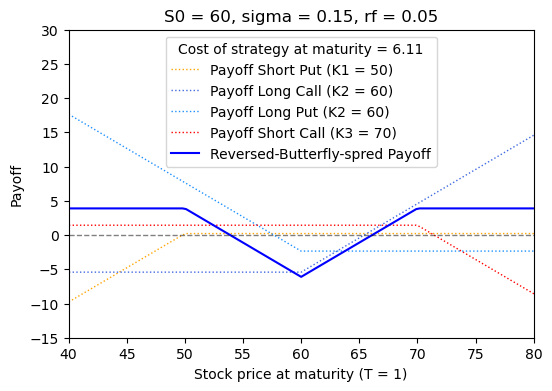

In [25]:
S0 = 60
sigma = 0.15
rf = 0.05
t = 1

K1, K3 = 50, 70
K2 = S0
St = np.linspace(0, 120, 401)
# Present day value of options
Pe0_K1 = bsm_option_prices(S0, K1, rf, sigma, t)['put']
Ce0_K2 = bsm_option_prices(S0, K2, rf, sigma, t)['call']
Pe0_K2 = bsm_option_prices(S0, K2, rf, sigma, t)['put']
Ce0_K3 = bsm_option_prices(S0, K3, rf, sigma, t)['call']

# Maturity value of options
PeT_K1 = Pe0_K1 * np.exp(rf * t) # sell 1
CeT_K2 = Ce0_K2 * np.exp(rf * t) # buy 1
PeT_K2 = Pe0_K2 * np.exp(rf * t) # buy 1
CeT_K3 = Ce0_K3 * np.exp(rf * t) # sell 1

# Cost of strategy at maturity
cost_of_strategy = round(CeT_K2 + PeT_K2 - PeT_K1 - CeT_K3, 2)

# Payoffs
poff_put1 = PeT_K1 - payoff_put(St, K1)
poff_call2 = payoff_call(St, K2) - CeT_K2
poff_put2 = payoff_put(St, K2) - PeT_K2
poff_call3 = CeT_K3 - payoff_call(St, K3)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.set_title(f'S0 = {S0}, sigma = {sigma}, rf = {rf}')
ax.plot(St, poff_put1, lw=1, ls=':', color='orange', label=f'Payoff Short Put (K1 = {K1})')
ax.plot(St, poff_call2, lw=1, ls=':', color='royalblue', label=f'Payoff Long Call (K2 = {K2})')
ax.plot(St, poff_put2, lw=1, ls=':', color='dodgerblue', label=f'Payoff Long Put (K2 = {K2})')
ax.plot(St, poff_call3, lw=1, ls=':', color='red', label=f'Payoff Short Call (K3 = {K3})')
ax.plot(St, poff_put1 + poff_call2 + poff_put2 + poff_call3, color='blue', label='Reversed-Butterfly-spred Payoff')
ax.axhline(0, lw=1, ls="--", color='black', alpha=0.5)
ax.set_xlim(40, 80)
ax.set_ylim(-15, 30)
ax.set_xlabel(f'Stock price at maturity (T = {t})')
ax.set_ylabel('Payoff')
ax.legend(title=f"Cost of strategy at maturity = {cost_of_strategy}")
plt.show()